# UNSW-NB15

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

## 1. Завантаження та первинний аналіз

In [2]:
dataset_dir = Path(
    kagglehub.dataset_download("dhoogla/unswnb15")
)

train_path = next(
    path
    for path in dataset_dir.rglob("*.parquet")
    if "train" in path.name.lower()
)

df = pd.read_parquet(train_path)

print("Shape:", df.shape)
print(df.columns.tolist())

df.head()

Shape: (175341, 36)
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-null

### Features / target

In [4]:
X = df.drop(columns=["label", "attack_cat"])
y = df["label"]

print("Features:", X.shape)
print("Target:", y.name)

Features: (175341, 34)
Target: label


### Класи

In [5]:
class_counts = y.value_counts().sort_index()
class_share = y.value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame(
    {
        "count": class_counts,
        "share, %": class_share.round(2),
    }
)

class_summary.index = ["Normal", "Attack"]
class_summary

,count,"share, %"
Normal,56000,31.94
Attack,119341,68.06


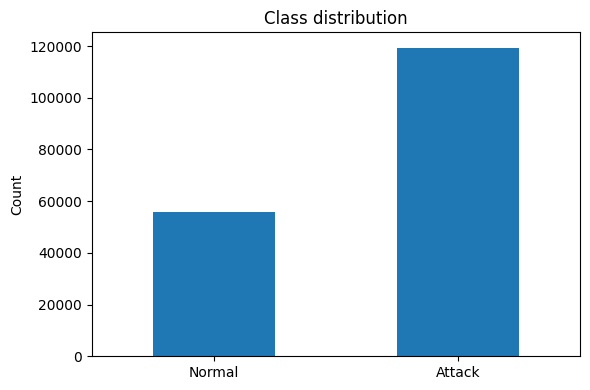

In [6]:
class_counts.rename(
    index={0: "Normal", 1: "Attack"}
).plot(
    kind="bar",
    figsize=(6, 4),
)

plt.title("Class distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Попередня обробка

### Пропуски

In [7]:
missing = df.isna().sum()
missing[missing > 0]

Series([], dtype: int64)

### Типи ознак

In [8]:
categorical_features = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print("Categorical:", categorical_features)
print("Numeric:", len(numeric_features))

Categorical: ['proto', 'service', 'state']
Numeric: 31


`proto`, `service` і `state` -- категоріальні ознаки.

Для них далі використовується One-Hot Encoding.

`attack_cat` не входить у features, бо вона вже описує тип атаки.

## 3. EDA

Ознак багато, тому для графіків беремо 10 числових ознак
з найбільшою абсолютною кореляцією з `label`.

In [9]:
target_corr = (
    df[numeric_features + ["label"]]
    .corr()["label"]
    .drop("label")
    .abs()
    .sort_values(ascending=False)
)

eda_features = target_corr.head(10).index.tolist()
target_corr.head(10)

dload               0.393739
ct_dst_sport_ltm    0.357213
dmean               0.341806
rate                0.337979
swin                0.333633
dwin                0.319626
ct_src_dport_ltm    0.305579
stcpb               0.255006
dtcpb               0.250340
is_sm_ips_ports     0.184679
Name: label, dtype: float64

### Heatmap

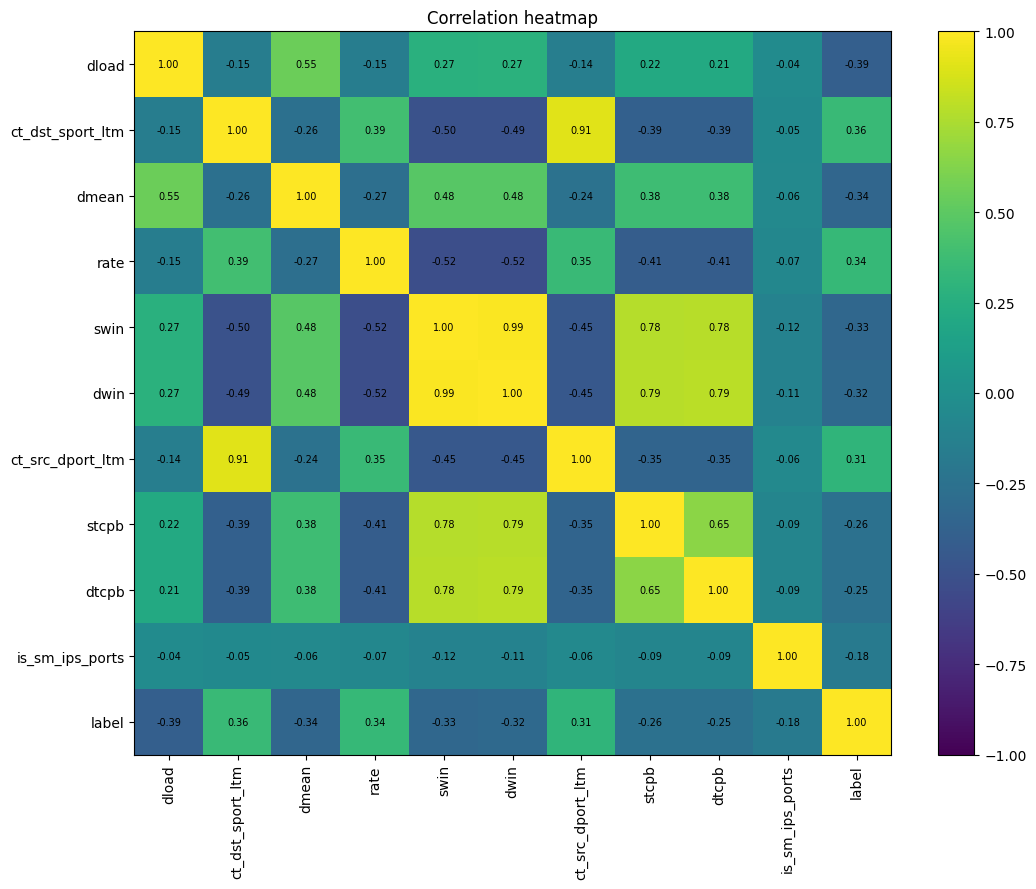

In [10]:
corr = df[eda_features + ["label"]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(
    corr,
    vmin=-1,
    vmax=1,
    aspect="auto",
)

fig.colorbar(image, ax=ax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

for row in range(len(corr.index)):
    for column in range(len(corr.columns)):
        ax.text(
            column,
            row,
            f"{corr.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )

ax.set_title("Correlation heatmap")
plt.tight_layout()
plt.show()

### Histograms

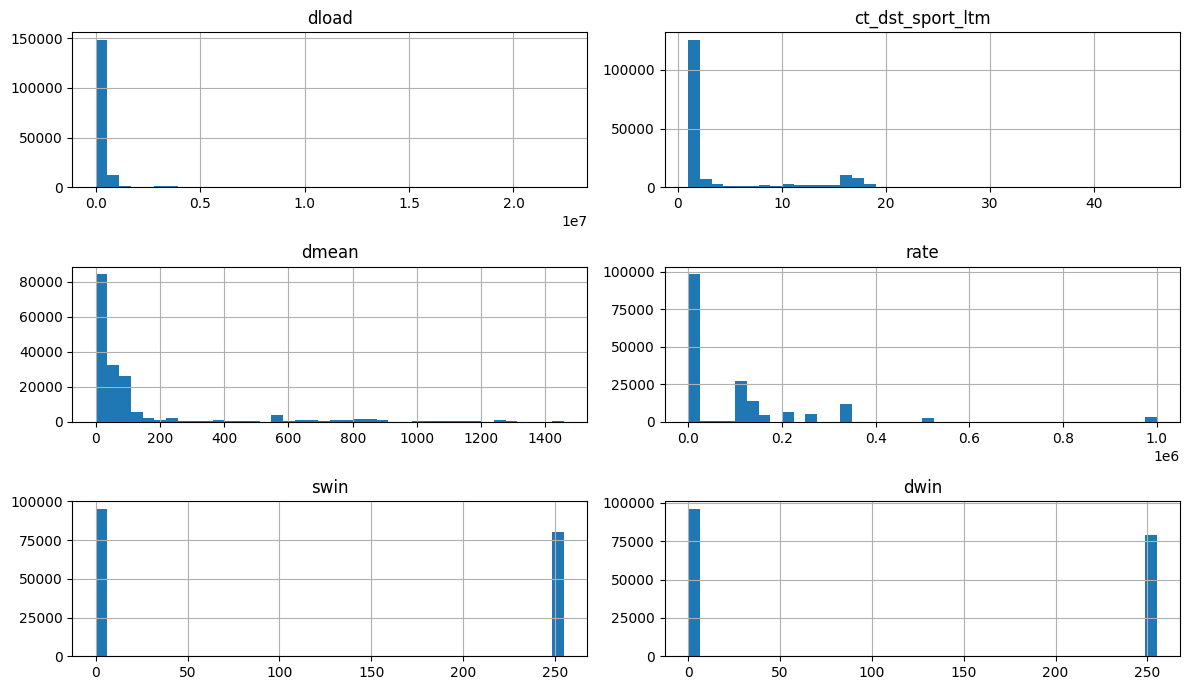

In [11]:
df[eda_features[:6]].hist(
    bins=40,
    figsize=(12, 7),
)

plt.tight_layout()
plt.show()

### Boxplots

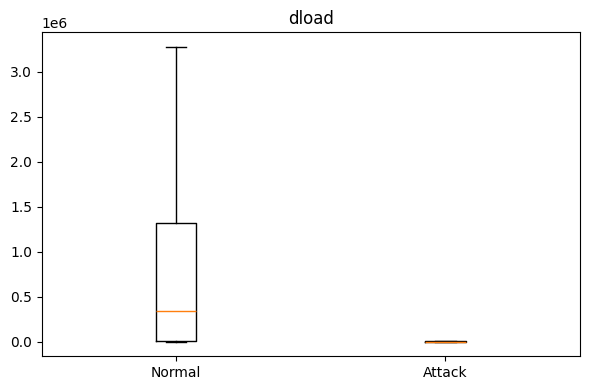

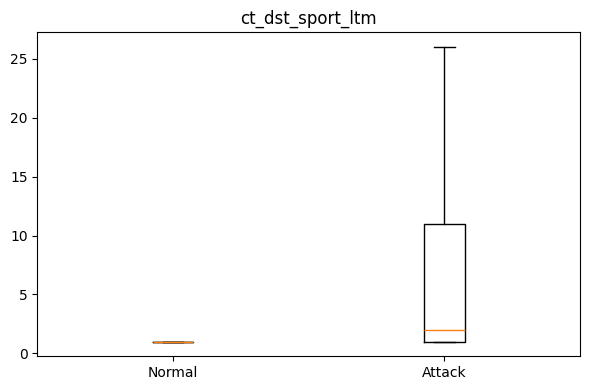

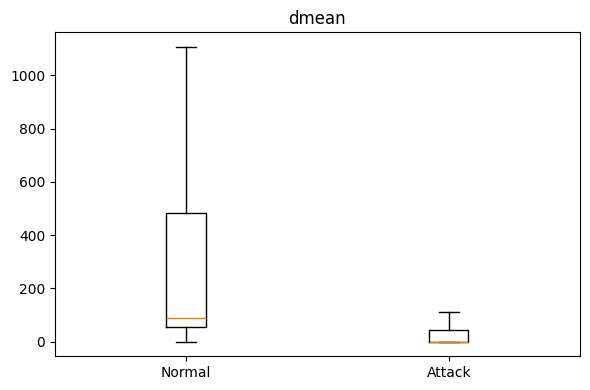

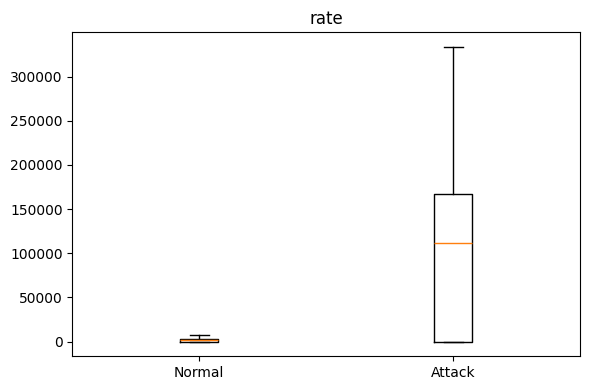

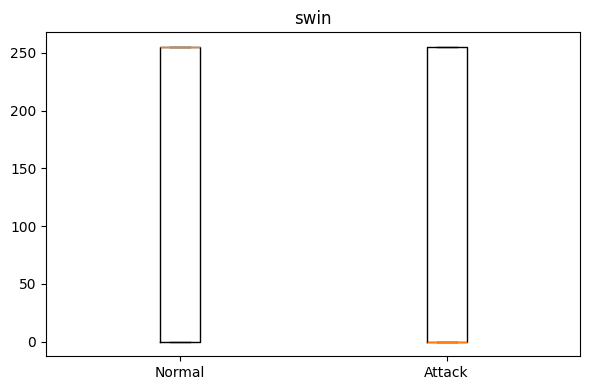

In [12]:
for feature in eda_features[:5]:
    normal = df.loc[df["label"] == 0, feature]
    attack = df.loc[df["label"] == 1, feature]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(
        [normal, attack],
        tick_labels=["Normal", "Attack"],
        showfliers=False,
    )
    ax.set_title(feature)

    plt.tight_layout()
    plt.show()

Heatmap -- зв'язок ознак між собою.

Histograms -- форма розподілу.

Boxplot -- різниця між Normal і Attack.

## 4. Train / test

Для моделей використовуємо 50 000 записів, щоб kNN і SVM
нормально рахувалися локально.

In [13]:
X_model, _, y_model, _ = train_test_split(
    X,
    y,
    train_size=50_000,
    random_state=42,
    stratify=y,
)

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model,
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (40000, 34)
Test: (10000, 34)


### Preprocessing

In [14]:
scaled_preprocessor = ColumnTransformer(
    [
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

tree_preprocessor = ColumnTransformer(
    [
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

kNN і SVM отримують масштабовані числові ознаки.

Для Decision Tree, Random Forest і AdaBoost масштабування не потрібне.

## 5. Моделі

Використовуємо kNN, Decision Tree, SVM, Random Forest та AdaBoost.

Для kNN і SVM спочатку підберемо параметри, потім навчимо всі
фінальні моделі один раз.

## 6. Підбір параметрів

### kNN

In [15]:
k_values = [3, 5, 7, 9, 11, 15]
k_scores = []

for k in k_values:
    model = Pipeline(
        [
            ("preprocessor", scaled_preprocessor),
            (
                "classifier",
                KNeighborsClassifier(n_neighbors=k),
            ),
        ]
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="f1",
        n_jobs=-1,
    ).mean()

    k_scores.append(score)

best_k = k_values[int(np.argmax(k_scores))]
print("Best k:", best_k)

Best k: 15


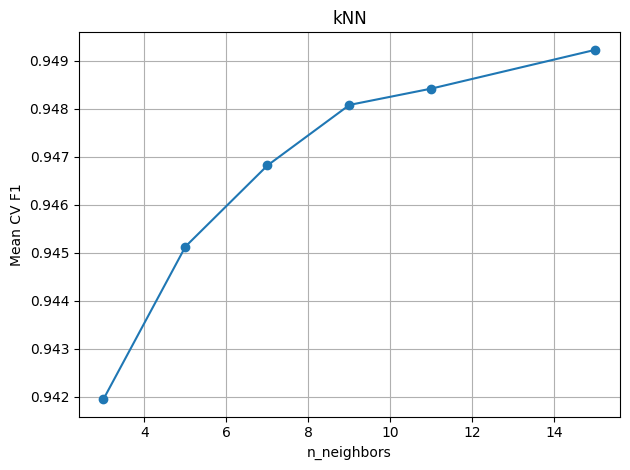

In [16]:
plt.plot(k_values, k_scores, marker="o")
plt.xlabel("n_neighbors")
plt.ylabel("Mean CV F1")
plt.title("kNN")
plt.grid()
plt.tight_layout()
plt.show()

### SVM

In [17]:
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=20_000,
    random_state=42,
    stratify=y_train,
)

svm = Pipeline(
    [
        ("preprocessor", scaled_preprocessor),
        ("classifier", SVC(kernel="rbf")),
    ]
)

param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__gamma": [
        "scale",
        0.01,
        0.001,
    ],
}

grid = GridSearchCV(
    svm,
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
)

grid.fit(X_tune, y_tune)

print("Best params:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 4))

Best params: {'classifier__C': 10, 'classifier__gamma': 'scale'}
Best CV F1: 0.9534


## 7. Порівняння моделей

In [18]:
models = {
    "kNN": Pipeline(
        [
            ("preprocessor", scaled_preprocessor),
            (
                "classifier",
                KNeighborsClassifier(
                    n_neighbors=best_k
                ),
            ),
        ]
    ),
    "Decision Tree": Pipeline(
        [
            ("preprocessor", tree_preprocessor),
            (
                "classifier",
                DecisionTreeClassifier(
                    random_state=42
                ),
            ),
        ]
    ),
    "SVM": Pipeline(
        [
            ("preprocessor", scaled_preprocessor),
            (
                "classifier",
                SVC(
                    kernel="rbf",
                    C=grid.best_params_["classifier__C"],
                    gamma=grid.best_params_[
                        "classifier__gamma"
                    ],
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("preprocessor", tree_preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=100,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "AdaBoost": Pipeline(
        [
            ("preprocessor", tree_preprocessor),
            (
                "classifier",
                AdaBoostClassifier(
                    random_state=42
                ),
            ),
        ]
    ),
}

### Classification report / confusion matrix


kNN
              precision    recall  f1-score   support

      Normal       0.95      0.84      0.89      3194
      Attack       0.93      0.98      0.95      6806

    accuracy                           0.93     10000
   macro avg       0.94      0.91      0.92     10000
weighted avg       0.93      0.93      0.93     10000



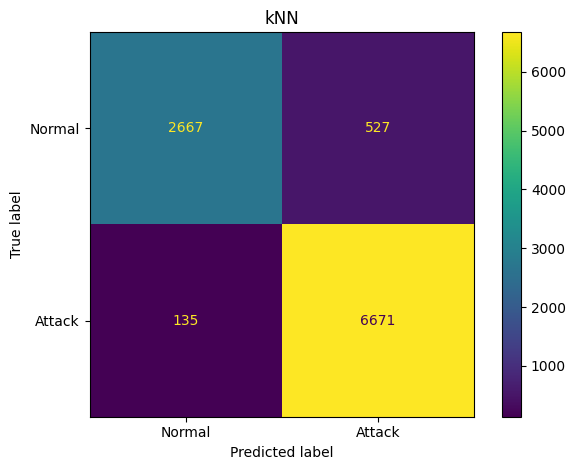


Decision Tree
              precision    recall  f1-score   support

      Normal       0.90      0.90      0.90      3194
      Attack       0.95      0.95      0.95      6806

    accuracy                           0.93     10000
   macro avg       0.93      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



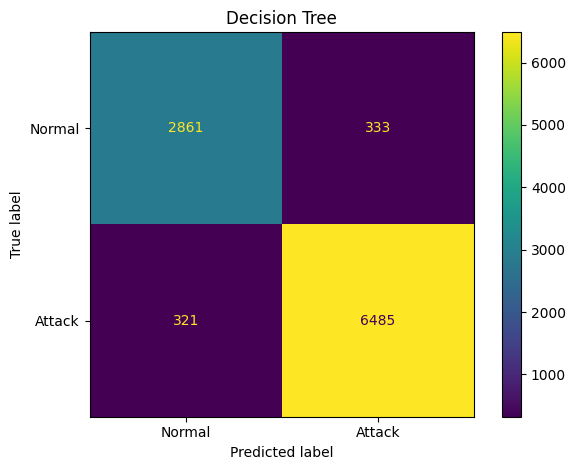


SVM
              precision    recall  f1-score   support

      Normal       0.99      0.81      0.89      3194
      Attack       0.92      1.00      0.95      6806

    accuracy                           0.94     10000
   macro avg       0.95      0.90      0.92     10000
weighted avg       0.94      0.94      0.93     10000



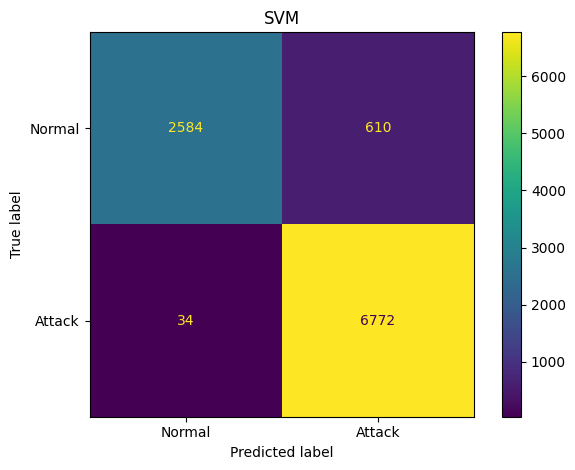


Random Forest
              precision    recall  f1-score   support

      Normal       0.94      0.88      0.91      3194
      Attack       0.95      0.97      0.96      6806

    accuracy                           0.95     10000
   macro avg       0.94      0.93      0.94     10000
weighted avg       0.95      0.95      0.94     10000



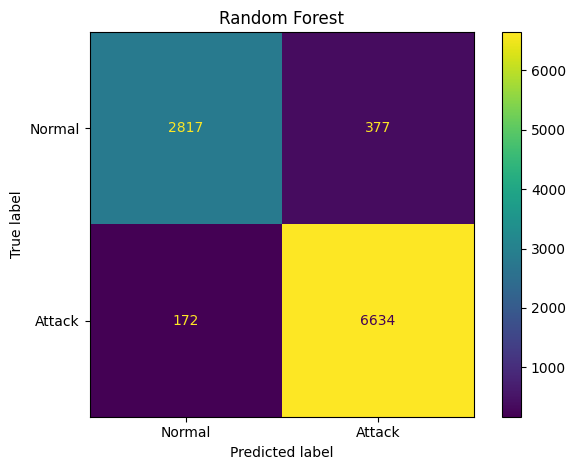


AdaBoost
              precision    recall  f1-score   support

      Normal       0.95      0.75      0.83      3194
      Attack       0.89      0.98      0.93      6806

    accuracy                           0.91     10000
   macro avg       0.92      0.86      0.88     10000
weighted avg       0.91      0.91      0.90     10000



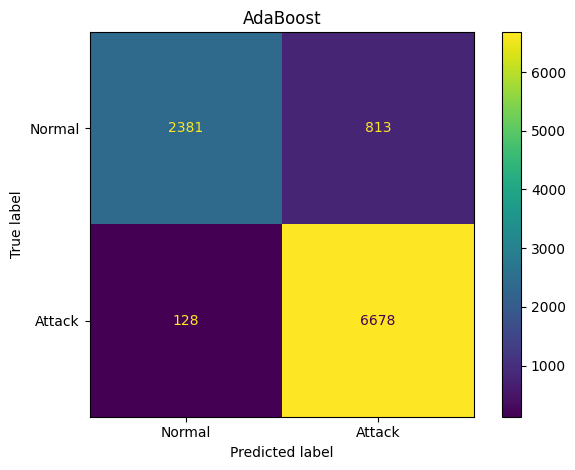

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.9451,0.946227,0.974728,0.960266
1,SVM,0.9356,0.917367,0.995004,0.954610
2,kNN,0.9338,0.926785,0.980165,0.952728
3,Decision Tree,0.9346,0.951159,0.952836,0.951996
4,AdaBoost,0.9059,0.891470,0.981193,0.934182


In [19]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Normal", "Attack"],
        )
    )

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Normal", "Attack"],
        values_format="d",
    )
    plt.title(name)
    plt.tight_layout()
    plt.show()

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
        }
    )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    "F1",
    ascending=False,
).reset_index(drop=True)

results_df

### Один графік

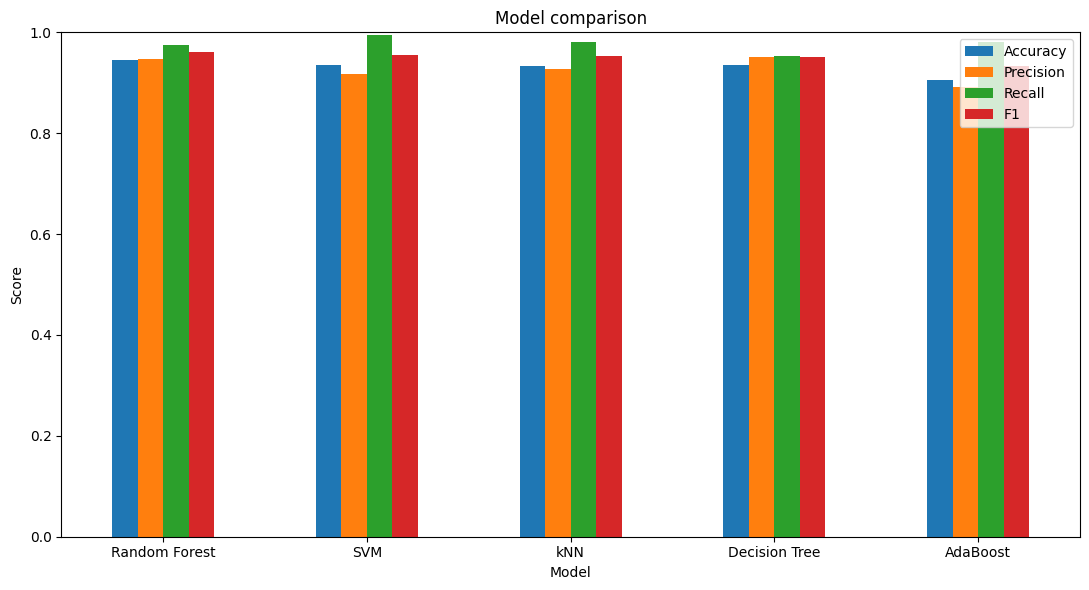

In [20]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1"]
].plot(
    kind="bar",
    figsize=(11, 6),
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Результат

In [21]:
best = results_df.iloc[0]

print(
    f"Best model: {best['Model']} | "
    f"F1 = {best['F1']:.4f}"
)

Best model: Random Forest | F1 = 0.9603


## Висновок

Після запуску тут достатньо коротко написати:
хто має найкращий F1, хто краще ловить атаки за Recall,
і де менше FP / FN.